In [58]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.font_manager as fm

font_path = "../01_wasting_stunting/Microsoft Aptos Fonts/Aptos.ttf"  
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()

import os

# Compare it to Last Year

In [59]:
annual_immunization_df = pd.read_csv('outputs/annual_immunization.csv')
annual_immunization_df['PSGC'] = annual_immunization_df['PSGC'].astype(str).str.zfill(10)

region_df = annual_immunization_df[annual_immunization_df.Income.isnull()].copy()

In [60]:
region2024_df = region_df[region_df.Year == 2025].copy()
region2024_df['FIC_eligible'] = region2024_df['FIC_Total'] / (region2024_df['FIC_Percent'] / 100)
national_baseline = region2024_df['FIC_Total'].sum() / region2024_df['FIC_eligible'].sum()
print(f'The 2024 national baseline is {(national_baseline * 100):.2f}%.')

The 2024 national baseline is 64.54%.


# 1. Get the FIC Coverage by the Municipality and by Income

In [61]:
# Standardizing Income
income_map = {
    # 1st class variants
    '1st': '1st',
    '1st*': '1st',
    '1st (as Mun)': '1st',
    '1st* (reclass 2005)': '1st',

    # 2nd class
    '2nd': '2nd',
    '2nd*': '2nd',

    # 3rd class
    '3rd': '3rd',
    '3rd*': '3rd',

    # 4th class
    '4th': '4th',
    '4th*': '4th',

    # 5th class
    '5th': '5th',
    '5th*': '5th',

    # 6th class
    '6th': '6th',
    '6th*': '6th',

    # Special cases
    'Special': '1st',   # treat as 1st
    '-': np.nan        # or keep as '-' if needed
}

In [62]:
LGU_fic_df = pd.read_csv('outputs/annual2025_immunization.csv')

# Standardize Income and PSGC
LGU_fic_df['Income'] = LGU_fic_df['Income'].map(income_map)
LGU_fic_df.PSGC = LGU_fic_df.PSGC.astype(str).str.zfill(10)

def classify_coverage(x):
    if x >= 75:
        return '1st Quartile'
    elif x >= 50:
        return '2nd Quartile'
    elif x >= 25:
        return '3rd Quartile'
    else:
        return '4th Quartile'

def is_reach_target(x):
    if x >= 95:
        return True
    return False


LGU_fic_df['Coverage_Level'] = LGU_fic_df['FIC_Percent'].apply(classify_coverage)
LGU_fic_df['Reached_Target'] = LGU_fic_df['FIC_Percent'].apply(is_reach_target)
LGU_fic_df.reset_index(inplace=True)
LGU_fic_df.Coverage_Level.value_counts(normalize=True)

Coverage_Level
2nd Quartile    0.566839
3rd Quartile    0.230637
1st Quartile    0.191624
4th Quartile    0.010901
Name: proportion, dtype: float64

In [63]:
LGU_fic_df['Income']= LGU_fic_df.PSGC.map(psgc_income_map)
ct = pd.crosstab(
    LGU_fic_df['Income'],
    LGU_fic_df['Coverage_Level'],
    normalize=False,
    margins=True
)

ct

Coverage_Level,1st Quartile,2nd Quartile,3rd Quartile,4th Quartile,All
Income,,,,,
1st,93,232,57,2,384
2nd,41,117,41,1,200
3rd,61,156,79,4,300
4th,72,224,120,3,419
5th,47,157,77,2,283
6th,5,10,11,1,27
All,319,896,385,13,1613


In [64]:
LGU_fic_df['Income']= LGU_fic_df.PSGC.map(psgc_income_map)
LGU_fic_df.groupby('Income')['Reached_Target'].value_counts()

Income  Reached_Target
1st     False             351
        True               33
2nd     False             187
        True               13
3rd     False             277
        True               23
4th     False             403
        True               16
5th     False             272
        True               11
6th     False              24
        True                3
Name: count, dtype: int64

# 2. Second, we want to see which vaccines are the most and least used.

<Axes: >

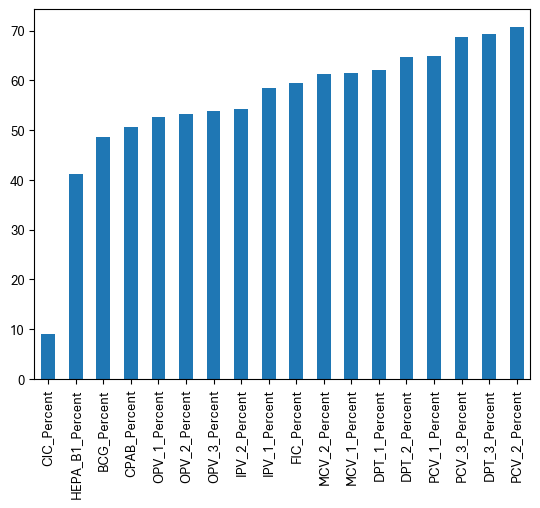

In [65]:
vac_cols = [vac_index for vac_index in LGU_fic_df.columns if vac_index.endswith('Percent')]
LGU_fic_df[vac_cols].median().sort_values().plot(kind='bar')

# 3. Choropleth - Find where the Vaccinations are Happening

In [66]:
folder_path = '../01_wasting_stunting/faeldon philippines-json-maps master 2023-geojson_provdists/hires'

gdfs = []

# Loop through all json files
for file in os.listdir(folder_path):
    if file.endswith('.json'):
        path = os.path.join(folder_path, file)
        gdf = gpd.read_file(path)
        gdfs.append(gdf)

# Combine into one GeoDataFrame
geo_df = pd.concat(gdfs, ignore_index=True)
geo_df['adm2_psgc'] = geo_df['adm2_psgc'].astype(str).str.zfill(10)

LGU_geo_df = geo_df.merge(
    LGU_fic_df,
    left_on='adm3_en',
    right_on='Area',
    how='left'
)

LGU_geo_df.Coverage_Level = LGU_geo_df.Coverage_Level.fillna('2nd Quartile')

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_14740/2644968396.py:19: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  LGU_geo_df.plot(


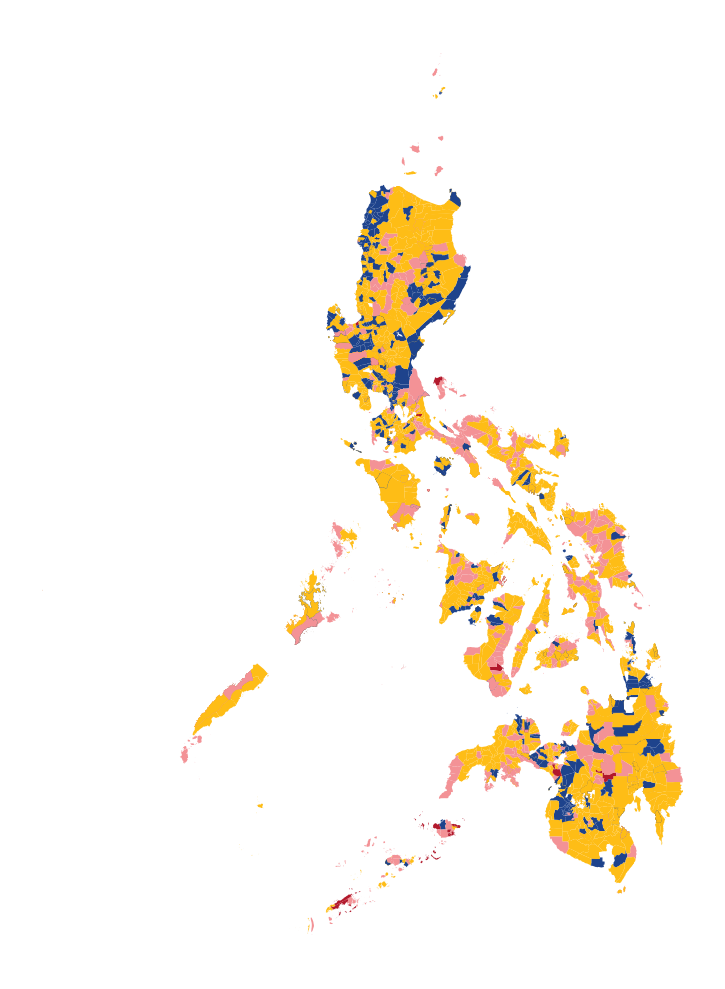

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Define color mapping by category
# color_map = {
#     '4th Quartile': '#e9252f',  # Red
#     '3rd Quartile': '#febd16',               # Yellow
#     '2nd Quartile': '#1e438c', #Blue
#     '1st Quartile': '#4CAF50'               # Green
# }

color_map = {
    '4th Quartile': '#b2182b',  # red (worst)
    '3rd Quartile': '#f39296',  # light red / neutral
    '2nd Quartile': '#febd16',  # light blue / neutral
    '1st Quartile': '#1e438c'   # blue (best)
}

# Plot directly using GeoPandas categorical mapping
LGU_geo_df.plot(
    column='Coverage_Level',
    legend=True,
    #legend_kwds={'title': 'Coverage Level', 'loc': 'lower right'},
    color=LGU_geo_df['Coverage_Level'].map(color_map),
    linewidth=0.1,
    #edgecolor='white',
    ax=ax
)

ax.axis('off')
plt.tight_layout()
plt.show()

# 4. See the Growth Rate

In [68]:
# Get the average annual growth rate in FIC coverage from 2018–2025
df = region_df.sort_values(['PSGC', 'Year'])
df['growth_rate'] = df.groupby('PSGC')['FIC_Percent'].pct_change()
df['growth_factor'] = 1 + df['growth_rate']
gmean_growth = (
    df.groupby('PSGC')['growth_factor']
    .apply(lambda x: np.prod(x) ** (1 / len(x)))
)
gmean_growth_rate = gmean_growth - 1
province_names = df[['PSGC', 'Area']].drop_duplicates().set_index('PSGC')

result = province_names.join(gmean_growth_rate.rename('avg_annual_growth'))

result['Area'] = result['Area'].replace({
    'NEGROS ISLAND REGION (NIR)': 'NIR'
})

# set an order
region_order = [
    'NCR', 'CAR', 'Region 1', 'Region 2', 'Region 3', 'Region 4A',
    'Region 4B', 'Region 5', 'Region 6', 'NIR',
    'Region 7', 'Region 8', 'Region 9', 'Region 10',
    'Region 11', 'Region 12', 'Region 13', 'BARMM'
]

region_order = [region.upper() for region in region_order]

result_ordered = (
    result
    .set_index('Area')
    .loc[region_order]   # this enforces the order
    .reset_index()
)

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_14740/3097740473.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(result_ordered.Area, rotation=45, ha='right', rotation_mode='anchor')


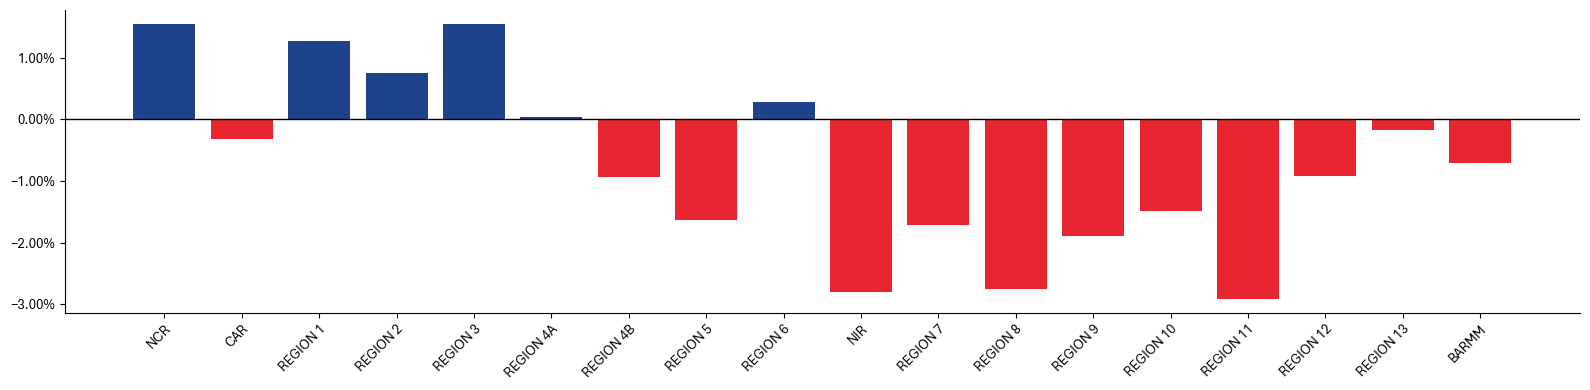

In [69]:
fig, ax = plt.subplots(figsize=(16, 4))

# Assign colors based on sign
colors = np.where(
    result_ordered.avg_annual_growth >= 0,
    '#1e438c',  # blue
    '#e9252f'   # red
)

ax.bar(result_ordered.Area, result_ordered.avg_annual_growth, color=colors)

ax.set_xticklabels(result_ordered.Area, rotation=45, ha='right', rotation_mode='anchor')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  

ax.axhline(0, color='black', linewidth=1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [70]:
folder_path = '../01_wasting_stunting/faeldon philippines-json-maps master 2023-geojson_regions/hires'

gdfs = []

# Loop through all json files
for file in os.listdir(folder_path):
    if file.endswith('.json'):
        path = os.path.join(folder_path, file)
        gdf = gpd.read_file(path)
        gdfs.append(gdf)

# Combine into one GeoDataFrame
geo_df = pd.concat(gdfs, ignore_index=True)
geo_df.adm2_psgc = geo_df.adm2_psgc.astype(str).str.zfill(10)

prov_geo_df = geo_df.merge(
    gmean_growth_rate,
    left_on='adm2_psgc',
    right_on='PSGC',
    how='left'
)